# Import modules

In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Model PINN

In [26]:
class simpleModel(nn.Module):
  def __init__(self,
               hidden_size=20):
    super().__init__()
    self.layers_stack = nn.Sequential(
        nn.Linear(2, hidden_size),
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #1
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #2
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #3
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #4
        nn.Tanh(),
        nn.Linear(hidden_size, 1),
        nn.Tanh(),
    )

  def forward(self, x):
    return self.layers_stack(x)

# PDE (уравнение теплопроводности)

Рассмотрим задачу теплопроводности на отрезке:

$$
\begin{cases}
u_t = a u_{xx}, \quad x \in (0, 1), \\
u(0,t) = 0, \\
u(1,t) = 0, \\
u(x,0) = \sin(\pi x).
\end{cases}
$$

Здесь \(a > 0\) — коэффициент теплопроводности.

Для данной начальной формы точное решение имеет вид:

$$
u(x,t) = e^{-a\pi^2 t}\sin(\pi x).
$$

In [21]:
# ============================================================
# Параметры задачи теплопроводности
# ============================================================

a: float = 1.0

N_f = 1000   # точки внутри области для PDE residual
N_b = 100    # точки на границе
N_i = 100    # точки начального условия

# ============================================================
# Внутренние точки области
# x in (0, 1), t in (0, 1)
# ============================================================

x_f = torch.rand(N_f, 1).to(device)
t_f = torch.rand(N_f, 1).to(device)

x_f.requires_grad_(True)
t_f.requires_grad_(True)

xt_f = torch.cat([x_f, t_f], dim=1)

# ============================================================
# Граничные условия
# u(0,t) = 0, u(1,t) = 0
# ============================================================

t_b = torch.linspace(0, 1, N_b).unsqueeze(1).to(device)

x_b_left = torch.zeros_like(t_b).to(device)
x_b_right = torch.ones_like(t_b).to(device)

xt_b_left = torch.cat([x_b_left, t_b], dim=1)
xt_b_right = torch.cat([x_b_right, t_b], dim=1)

u_b_left_true = torch.zeros_like(t_b).to(device)
u_b_right_true = torch.zeros_like(t_b).to(device)

# ============================================================
# Начальное условие
# u(x,0) = sin(pi x)
# ============================================================

x_i = torch.linspace(0, 1, N_i).unsqueeze(1).to(device)
t_i = torch.zeros_like(x_i).to(device)

xt_i = torch.cat([x_i, t_i], dim=1)

u_i_true = torch.sin(torch.pi * x_i)

In [17]:
def pde(out, x, t, a):

    # Первая производная по времени: u_t
    du_dt = torch.autograd.grad(
        out,
        t,
        torch.ones_like(out),
        create_graph=True,
        retain_graph=True
    )[0]

    # Первая производная по пространству: u_x
    du_dx = torch.autograd.grad(
        out,
        x,
        torch.ones_like(out),
        create_graph=True,
        retain_graph=True
    )[0]

    # Вторая производная по пространству: u_xx
    d2u_dx2 = torch.autograd.grad(
        du_dx,
        x,
        torch.ones_like(du_dx),
        create_graph=True,
        retain_graph=True
    )[0]

    # Невязка уравнения теплопроводности
    return du_dt - a * d2u_dx2

In [23]:
# Точное решение задачи
def exact_solution(x, t, a):
    return torch.exp(-a * torch.pi**2 * t) * torch.sin(torch.pi * x)

# Parameters of the task

In [24]:
def pdeBC(x_f, t_f, xt_f, a,
    xt_b_left, xt_b_right, xt_i,
    u_b_left_true, u_b_right_true, u_i_true,
    w_bc=1e3, w_ic=1e3, w_pde=1.0
):
    # ============================================================
    # 1. PDE loss
    # ============================================================

    # Предсказание модели во внутренних точках области
    u_f_pred = model(xt_f).to(device)
    # Невязка уравнения теплопроводности
    f1 = pde(u_f_pred, x_f, t_f, a)

    loss_pde = metric_data(f1, torch.zeros_like(f1))

    # ============================================================
    # 2. Boundary loss
    # ============================================================

    u_b_left_pred = model(xt_b_left).to(device)
    u_b_right_pred = model(xt_b_right).to(device)

    loss_bc_left = metric_data(u_b_left_pred, u_b_left_true)
    loss_bc_right = metric_data(u_b_right_pred, u_b_right_true)

    loss_bc = loss_bc_left + loss_bc_right

    # ============================================================
    # 3. Initial condition loss (Начальное условие: t = 0)
    # ============================================================

    u_i_pred = model(xt_i).to(device)
    loss_ic = metric_data(u_i_pred, u_i_true)

    # ============================================================
    # 4. Diagnostic metric against exact solution
    # ============================================================

    u_f_true = exact_solution(x_f, t_f, a).to(device)
    metric_u = metric_data(u_f_pred, u_f_true)

    # ============================================================
    # 5. Total loss
    # ============================================================

    loss = w_bc * loss_bc + w_ic * loss_ic + w_pde * loss_pde

    metrics = {
        "loss": loss,
        "loss_bc": loss_bc,
        "loss_bc_left": loss_bc_left,
        "loss_bc_right": loss_bc_right,
        "loss_ic": loss_ic,
        "loss_pde": loss_pde,
        "metric_u": metric_u,
    }

    return loss, metrics

In [27]:
steps=200

# Создаем модель 
model = simpleModel().to(device)

# Мрогресс-бар
pbar = tqdm(range(steps), desc='Training Progress')

# Метрика и оптимизатор 
metric_data = nn.MSELoss()
optimizer = torch.optim.LBFGS(model.parameters(), lr=0.1)


def train():
    metrics = []
    for step in pbar:

        def closure():
            optimizer.zero_grad()
            loss, metric = pdeBC(x_f, t_f, xt_f, a,
                                 xt_b_left, xt_b_right, xt_i,
                                 u_b_left_true, u_b_right_true, u_i_true,
            )
            metrics.append(metric)
            loss.backward()
            return loss

        optimizer.step(closure)
        if step % 2 == 0:
            current_loss = closure().item()
            pbar.set_description("Step: %d | Loss: %.6f" %
                                 (step, current_loss))
    return metrics

metrics = train()

Step: 198 | Loss: 0.002388: 100%|██████████| 200/200 [03:21<00:00,  1.01s/it]


In [28]:
loss = []
loss_bc = []
loss_pde = []

for step in metrics:
    loss.append(step['loss'].item()) 
    loss_bc.append(step['loss_bc'].item())
    loss_pde.append(step['loss_pde'].item())

# Predict values

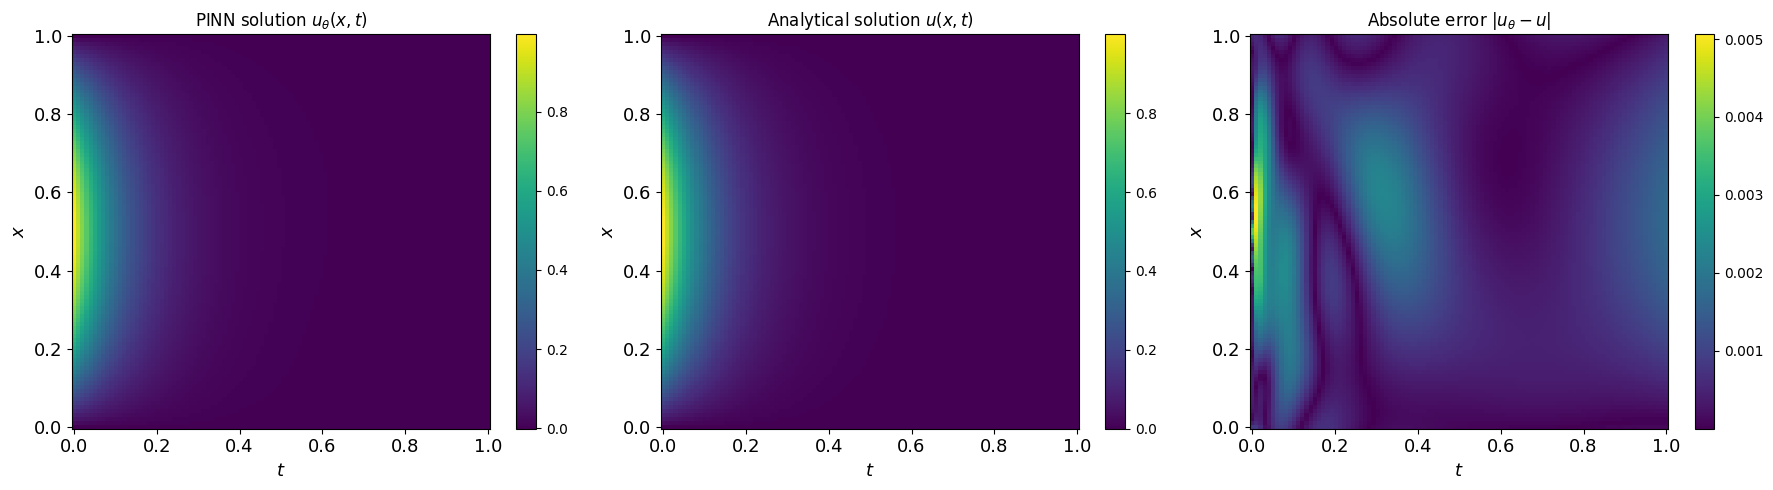

In [30]:
# ============================================================
# Визуализация решения уравнения теплопроводности
# ============================================================

model.eval()

# Сетка для визуализации
N_x_plot = 100
N_t_plot = 100

x_plot = torch.linspace(0, 1, N_x_plot).unsqueeze(1).to(device)
t_plot = torch.linspace(0, 1, N_t_plot).unsqueeze(1).to(device)

# Создаем двумерную сетку (x, t)
X, T = torch.meshgrid(
    x_plot.squeeze(),
    t_plot.squeeze(),
    indexing="ij"
)

# Превращаем сетку в список точек вида [x, t]
xt_plot = torch.cat(
    [
        X.reshape(-1, 1),
        T.reshape(-1, 1)
    ],
    dim=1
).to(device)

# Предсказание модели
with torch.no_grad():
    u_pred = model(xt_plot)

# Аналитическое решение
u_true = exact_solution(
    xt_plot[:, 0:1],
    xt_plot[:, 1:2],
    a
)

# Возвращаем к форме двумерной сетки
U_pred = u_pred.reshape(N_x_plot, N_t_plot).cpu().numpy()
U_true = u_true.reshape(N_x_plot, N_t_plot).cpu().numpy()
U_error = np.abs(U_pred - U_true)

X_np = X.cpu().numpy()
T_np = T.cpu().numpy()


# ============================================================
# Тепловые карты: PINN, аналитическое решение, ошибка
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PINN solution
im0 = axes[0].pcolormesh(
    T_np,
    X_np,
    U_pred,
    shading="auto"
)
axes[0].set_title(r"PINN solution $u_\theta(x,t)$")
axes[0].set_xlabel(r"$t$", fontsize=fs)
axes[0].set_ylabel(r"$x$", fontsize=fs)
axes[0].tick_params(axis="both", labelsize=fs)
fig.colorbar(im0, ax=axes[0])

# Exact solution
im1 = axes[1].pcolormesh(
    T_np,
    X_np,
    U_true,
    shading="auto"
)
axes[1].set_title(r"Analytical solution $u(x,t)$")
axes[1].set_xlabel(r"$t$", fontsize=fs)
axes[1].set_ylabel(r"$x$", fontsize=fs)
axes[1].tick_params(axis="both", labelsize=fs)
fig.colorbar(im1, ax=axes[1])

# Absolute error
im2 = axes[2].pcolormesh(
    T_np,
    X_np,
    U_error,
    shading="auto"
)
axes[2].set_title(r"Absolute error $|u_\theta - u|$")
axes[2].set_xlabel(r"$t$", fontsize=fs)
axes[2].set_ylabel(r"$x$", fontsize=fs)
axes[2].tick_params(axis="both", labelsize=fs)
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig("heat_equation_solution_maps.png", dpi=200)
plt.show()

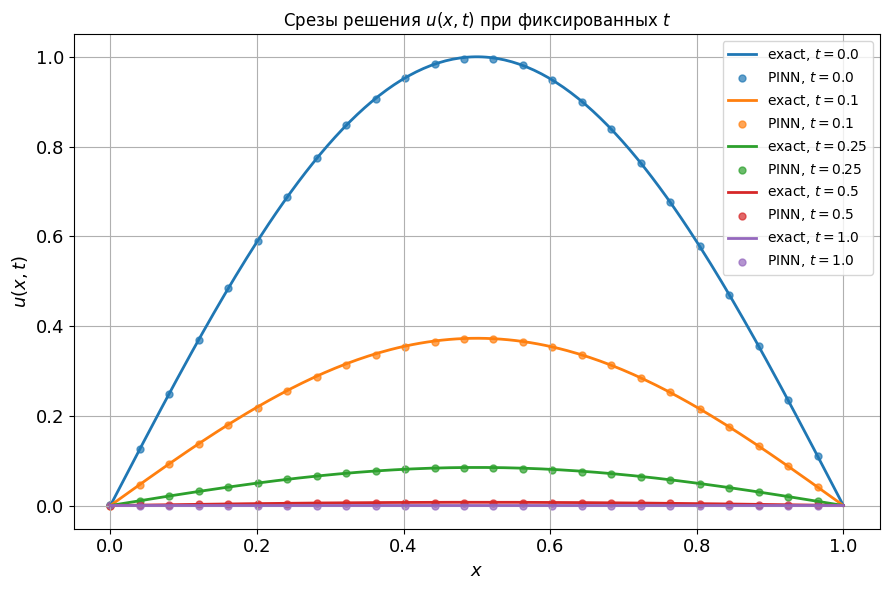

In [31]:
# ============================================================
# Сравнение срезов u(x,t) при фиксированных t
# ============================================================

model.eval()

t_slices = [0.0, 0.1, 0.25, 0.5, 1.0]

x_line = torch.linspace(0, 1, 200).unsqueeze(1).to(device)

plt.figure(figsize=(9, 6))

for t_value in t_slices:
    t_line = torch.full_like(x_line, t_value).to(device)
    xt_line = torch.cat([x_line, t_line], dim=1)

    with torch.no_grad():
        u_pred_line = model(xt_line)

    u_true_line = exact_solution(x_line, t_line, a)

    x_np = x_line.cpu().numpy()
    u_pred_np = u_pred_line.cpu().numpy()
    u_true_np = u_true_line.cpu().numpy()

    plt.plot(
        x_np,
        u_true_np,
        linewidth=2,
        label=fr"exact, $t={t_value}$"
    )

    plt.scatter(
        x_np[::8],
        u_pred_np[::8],
        s=25,
        alpha=0.7,
        label=fr"PINN, $t={t_value}$"
    )

plt.xlabel(r"$x$", fontsize=fs)
plt.ylabel(r"$u(x,t)$", fontsize=fs)
plt.title(r"Срезы решения $u(x,t)$ при фиксированных $t$")
plt.tick_params(axis="both", labelsize=fs)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.savefig("heat_equation_slices.png", dpi=200)
plt.show()

# history

C:\Users\user\AppData\Local\Temp\ipykernel_10812\2021547670.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(min(loss)-2*np.std(loss), max(loss)+2*np.std(loss))


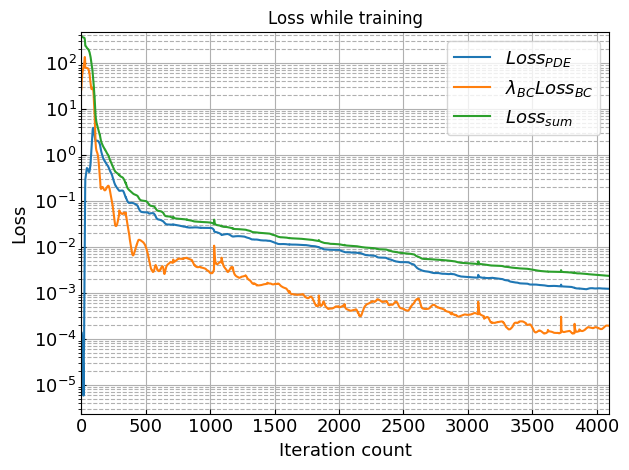

In [29]:
plt.plot(loss_pde, label=r'$Loss_{PDE}$')
plt.plot([1e3*i for i in loss_bc], label=r'$\lambda_{BC}Loss_{BC}$')
plt.plot(loss, label=r'$Loss_{sum}$')

ax=plt.gca()
ax.set_yscale('log')
plt.grid(which='major', linestyle='-')
plt.grid(which='minor', linestyle='--')
plt.xlim(0, len(loss))
plt.ylim(min(loss)-2*np.std(loss), max(loss)+2*np.std(loss))
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
ax.tick_params(axis='both',direction='in')

plt.legend(fontsize=fs)
plt.xlabel('Iteration count', fontsize=fs)
plt.ylabel('Loss', fontsize=fs)
plt.title('Loss while training')
plt.tight_layout()
plt.savefig('history_harm.png')
plt.show()